**Angie Carolina Joya Duarte - 2322609**  

**Sheila Marcela Valencia Chito - 2243011**

## 1) Preparar el dataset

Importar librerías

In [17]:
import os
import pandas as pd
import numpy as np
import random
import math
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

Definir las semillas

In [18]:
semilla = 42
random.seed(semilla)
np.random.seed(semilla)
tf.random.set_seed(semilla)

Leer dataset seleccionado: ibm.us.csv

In [19]:
path = os.path.join(os.getcwd(), "ibm.us.csv")
dataset = pd.read_csv(path)
dataset.head()

,Date,Open,High,Low,Close,Volume,OpenInt
0,1962-01-02,6.4130,6.4130,6.3378,6.3378,467056,0
1,1962-01-03,6.3378,6.3963,6.3378,6.3963,350294,0
2,1962-01-04,6.3963,6.3963,6.3295,6.3295,314365,0
3,1962-01-05,6.3211,6.3211,6.1958,6.2041,440112,0
4,1962-01-08,6.2041,6.2041,6.0373,6.0870,655676,0


### a) Graficar el promedio

In [20]:
dataset["promedioDia"] = (dataset["High"]+dataset["Low"])/2
dataset["Date"] = pd.to_datetime(dataset["Date"])
dataset.head()

,Date,Open,High,Low,Close,Volume,OpenInt,promedioDia
0,1962-01-02,6.4130,6.4130,6.3378,6.3378,467056,0,6.37540
1,1962-01-03,6.3378,6.3963,6.3378,6.3963,350294,0,6.36705
2,1962-01-04,6.3963,6.3963,6.3295,6.3295,314365,0,6.36290
3,1962-01-05,6.3211,6.3211,6.1958,6.2041,440112,0,6.25845
4,1962-01-08,6.2041,6.2041,6.0373,6.0870,655676,0,6.12070


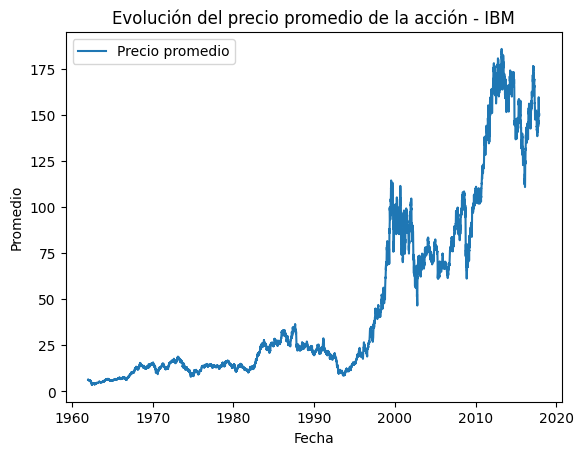

In [21]:
plt.plot(dataset["Date"], dataset["promedioDia"], label = "Precio promedio")
plt.title("Evolución del precio promedio de la acción - IBM")
plt.xlabel("Fecha")
plt.ylabel("Promedio")
plt.legend()
plt.show()

### b) Dividir los datos

In [22]:
#70% train, 15% validation, 15% test
n = len(dataset)

# train = dataset[:int(n*0.7)].copy()
# validation = dataset[int(n*0.7):int(n*0.85)].copy()
# test = dataset[int(n*0.85):].copy()

train = dataset[:int(n*0.7)][["promedioDia"]].to_numpy()
validation = dataset[int(n*0.7):int(n*0.85)][["promedioDia"]].to_numpy()
test = dataset[int(n*0.85):][["promedioDia"]].to_numpy()

print("Conjunto de entrenamiento: ",train[:5])
print("Conjunto de validación: ",validation[:5])
print("Conjunto de prueba: ",test[:5])

Conjunto de entrenamiento:  [[6.3754 ]
 [6.36705]
 [6.3629 ]
 [6.25845]
 [6.1207 ]]
Conjunto de validación:  [[96.151 ]
 [96.9425]
 [94.351 ]
 [94.384 ]
 [96.2135]]
Conjunto de prueba:  [[87.6125]
 [88.094 ]
 [85.8565]
 [84.6285]
 [84.332 ]]


### c) Normalizar los datos

Normalizar los datos

In [23]:
#Hallar la media y desviación del entrenamiento
media = train.mean()
desvest  = train.std()

#Normalizar los 3 subconjuntos respecto a los valores calculados
train = (train - media) / desvest
validation   = (validation   - media) / desvest
test  = (test  - media) / desvest

Creación de ventanas

In [24]:
#Ventanas de 30 días con muestras diarias
sampling_rate = 1
sequence_length = 15
delay = 1 
batch_size = 256

## 2) Modelo LSTM 

Preparar los dataset de acuerdo a la ventana de tiempo

In [25]:
train2D = train.reshape(-1, 1)
validation2D = validation.reshape(-1, 1)
test2D = test.reshape(-1, 1)

datasetTrain = keras.utils.timeseries_dataset_from_array(
  data = train2D[:-delay],
  targets=train2D[delay:],
  sampling_rate=sampling_rate,
  sequence_length=sequence_length,
  shuffle=True,
  batch_size=batch_size,
  start_index=0
  )

datasetValidation = keras.utils.timeseries_dataset_from_array(
  data = validation2D[:-delay],
  targets=validation2D[delay:],
  sampling_rate=sampling_rate,
  sequence_length=sequence_length,
  shuffle=True,
  batch_size=batch_size,
  start_index=0
  )

datasetTest = keras.utils.timeseries_dataset_from_array(
  data = test2D[:-delay],
  targets=test2D[delay:],
  sampling_rate=sampling_rate,
  sequence_length=sequence_length,
  shuffle=True,
  batch_size=batch_size,
  start_index=0
  )

Definir arquitectura de la red

In [26]:
cantNeuronas = 16
epocas = 20

In [27]:
inputs = keras.Input(shape=(sequence_length, 1))
x = layers.LSTM(cantNeuronas)(inputs) 
outputs = layers.Dense(1)(x)
LSTMBase = keras.Model(inputs, outputs)

Realizar el entrenamiento

In [28]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
]
LSTMBase.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

history = LSTMBase.fit(
    datasetTrain,
    epochs=epocas,
    validation_data=datasetValidation,
    callbacks=callbacks
)

print(f"MAE de las pruebas - LSTM: {LSTMBase.evaluate(datasetTest)[1]:.2f}")

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.3985 - mae: 0.2956 - val_loss: 1.6480 - val_mae: 1.1375
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.1209 - mae: 0.1377 - val_loss: 0.4108 - val_mae: 0.4562
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0394 - mae: 0.0875 - val_loss: 0.1420 - val_mae: 0.3287
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0115 - mae: 0.0537 - val_loss: 0.0379 - val_mae: 0.1511
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0062 - mae: 0.0433 - val_loss: 0.0209 - val_mae: 0.1045
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0050 - mae: 0.0388 - val_loss: 0.0183 - val_mae: 0.0959
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0048 - mae: 0.0373 - val_loss: 0.0173 - val_mae: 0.0939
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0043 - mae: 0.0360 - val_loss: 0.0186 - val_mae: 0.1040
Epoch 9/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.004

Evaluar los resultados

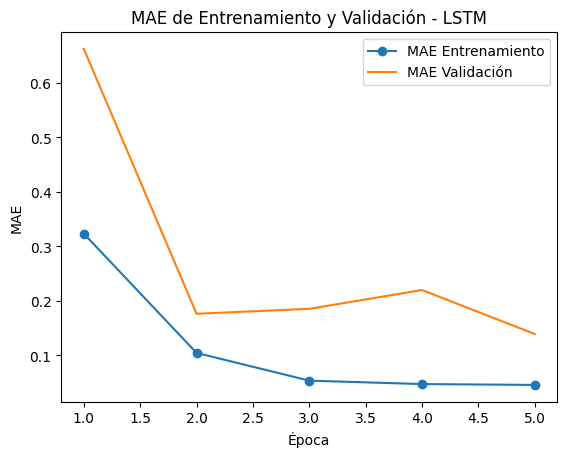

In [32]:
def graficaeMAE(history, titulo, ax=None):
  if ax is None:
    ax = plt.gca()

  loss = history.history["mae"]
  val_loss = history.history["val_mae"]
  epochs = range(1, len(loss) + 1)

  ax.plot(epochs, loss, "o-", label="MAE Entrenamiento")
  ax.plot(epochs, val_loss, "-", label="MAE Validación")
  ax.set_title(titulo)
  ax.set_xlabel("Época")
  ax.set_ylabel("MAE")
  ax.legend()

graficaeMAE(history, "MAE de Entrenamiento y Validación - LSTM")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  


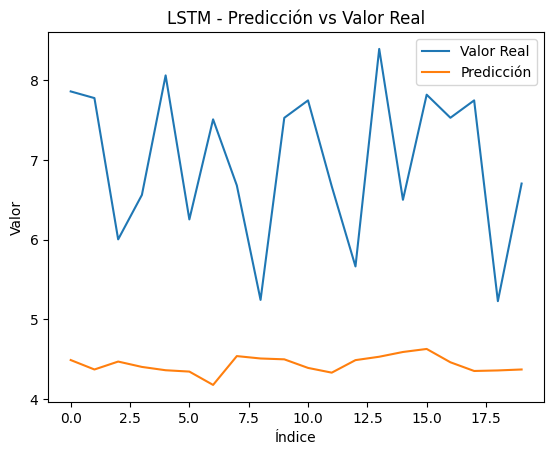

In [ ]:
prediccion = LSTMBase.predict(datasetTest)
y = np.concatenate([y for x, y in datasetTest], axis=0)

def graficarPrediccion(prediccion, y, titulo, rango=(20, 40), ax=None):
  if ax is None:
    ax = plt.gca()
        
  start, end = rango
  ax.plot(y[start:end], label="Valor Real")
  ax.plot(prediccion[start:end], label="Predicción")
  ax.set_title(titulo)
  ax.set_xlabel("Índice")
  ax.set_ylabel("Valor")
  ax.legend()

graficarPrediccion(prediccion, y, "LSTM - Predicción vs Valor Real")

Modificando el número de neuronas

In [ ]:
cantNeuronasLSTM = [5,15,30]
LSTMNeuronas = []

for i in range(len(cantNeuronasLSTM)):
  inputs = keras.Input(shape=(sequence_length, 1))
  x = layers.LSTM(cantNeuronasLSTM[i])(inputs)
  outputs = layers.Dense(1)(x)
  
  model = keras.Model(inputs, outputs)
  LSTMNeuronas.append(model)

histories = []
mae_tests = []

for i, model in enumerate(LSTMNeuronas):
  print(f"\nEntrenando modelo con {cantNeuronasLSTM[i]} neuronas LSTM...")
  
  model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
  
  history = model.fit(
    datasetTrain,
    epochs=epocas,
    validation_data=datasetValidation,
    callbacks=callbacks,
    verbose=0   # silencia las barras de progreso
  )
  
  # Guardar historial
  histories.append(history)
  
  # Evaluar modelo en test
  mae = model.evaluate(datasetTest, verbose=0)[1]
  mae_tests.append(mae)
  
  print(f"MAE de prueba ({cantNeuronasLSTM[i]} neuronas): {mae:.4f}")


Entrenando modelo con 5 neuronas LSTM...
MAE de prueba (5 neuronas): 6.5046

Entrenando modelo con 15 neuronas LSTM...
MAE de prueba (15 neuronas): 5.3159

Entrenando modelo con 30 neuronas LSTM...
MAE de prueba (30 neuronas): 4.2170


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  


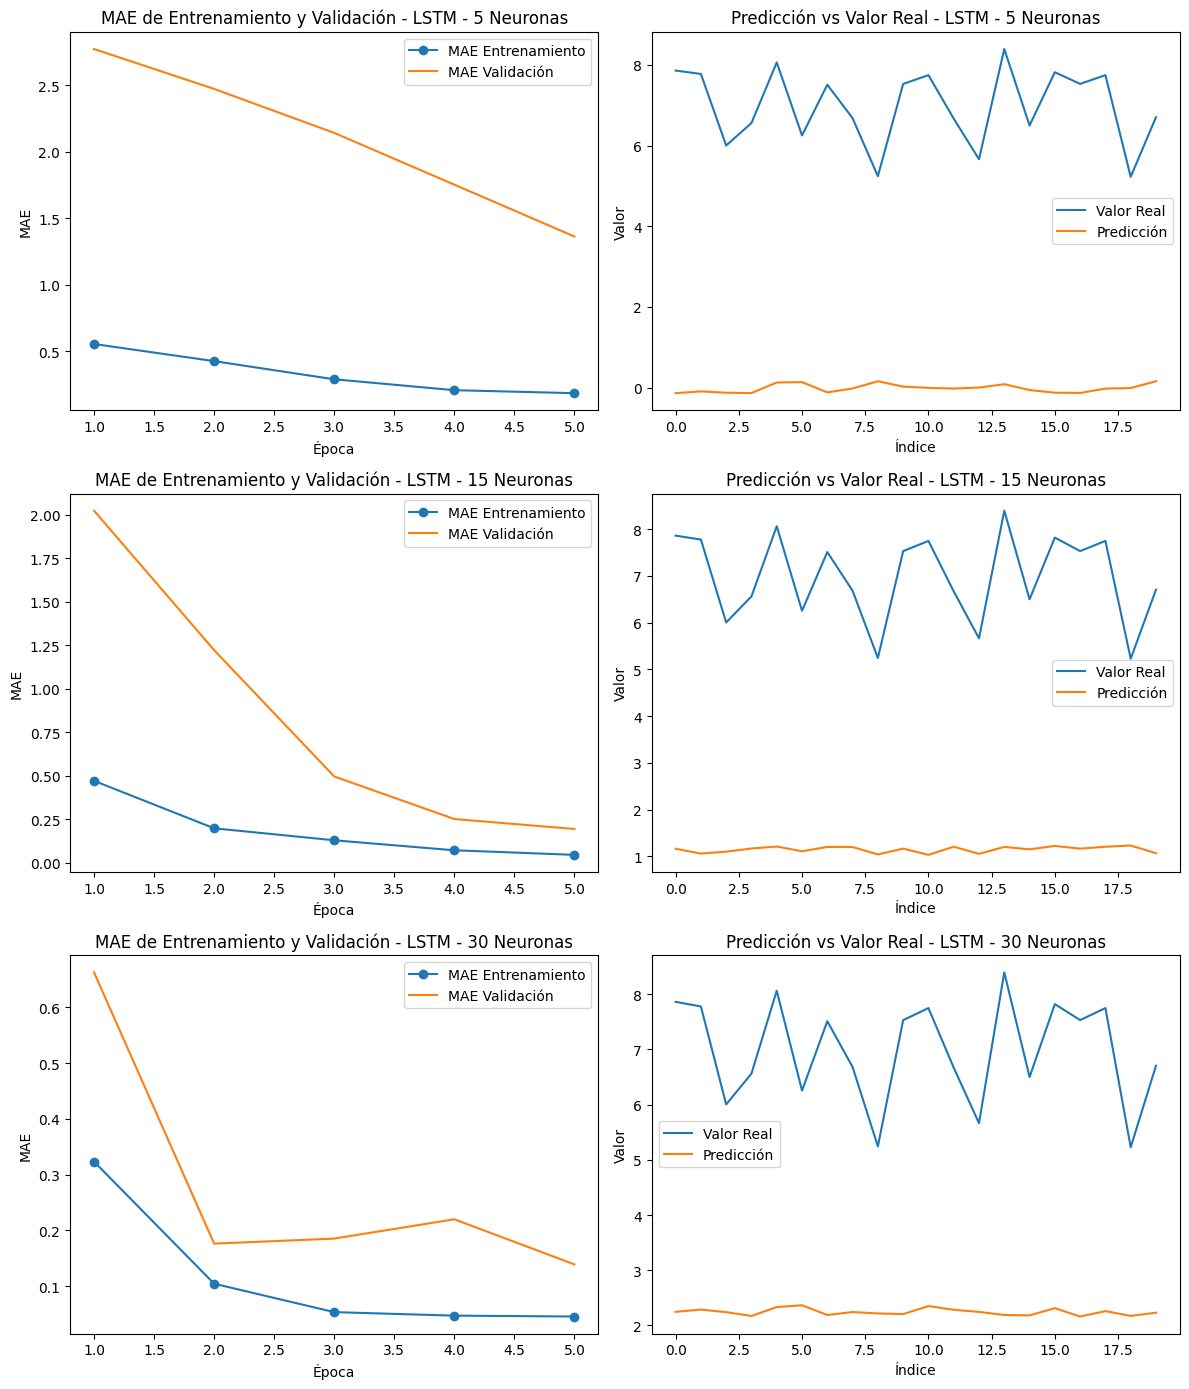

In [35]:
predicciones = [model.predict(datasetTest) for model in LSTMNeuronas]
fig, axes = plt.subplots(3, 2, figsize=(12, 14))

graficaeMAE(histories[0], "MAE de Entrenamiento y Validación - LSTM - 5 Neuronas", axes[0][0])
graficarPrediccion(prediccion=predicciones[0], y=y, titulo="Predicción vs Valor Real - LSTM - 5 Neuronas", ax=axes[0][1])

graficaeMAE(histories[1], "MAE de Entrenamiento y Validación - LSTM - 15 Neuronas", axes[1][0])
graficarPrediccion(prediccion=predicciones[1], y=y, titulo="Predicción vs Valor Real - LSTM - 15 Neuronas", ax=axes[1][1])

graficaeMAE(histories[2], "MAE de Entrenamiento y Validación - LSTM - 30 Neuronas", axes[2][0])
graficarPrediccion(prediccion=predicciones[2], y=y, titulo="Predicción vs Valor Real - LSTM - 30 Neuronas", ax=axes[2][1])

plt.tight_layout()
plt.show()